# Agentic-DEE Analysis
Analysis of agent-driven DEE parameter exploration across 1VII, 1PGB, and 1L2Y.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load experiment logs

In [5]:
LOG_FILE = Path("../data/logs/experiments.jsonl")

records = []
with open(LOG_FILE) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Loaded {len(records)} experiment records")

# Flatten into a DataFrame
rows = []
for r in records:
    row = {
        "id": r["id"],
        "timestamp": r["timestamp"],
        "protein": r["protein"],
        "run_type": r.get("run_type", "agent"),
        "rationale": r.get("rationale", ""),
        # parameters
        "ex1": r["parameters"].get("ex1", False),
        "ex2": r["parameters"].get("ex2", False),
        "ex1aro": r["parameters"].get("ex1aro", False),
        "use_input_sc": r["parameters"].get("use_input_sc", False),
        "designable_region": r["parameters"].get("designable_region", "all"),
        # metrics
        "initial_score": r["metrics"].get("initial_score"),
        "final_score": r["metrics"].get("final_score"),
        "score_improvement": r["metrics"].get("score_improvement"),
        "rotamers_pre_dee": r["metrics"].get("rotamers_pre_dee"),
        "runtime_seconds": r["metrics"].get("runtime_seconds"),
        "designable_residues": r["metrics"].get("designable_residues"),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601", utc=True)

# Create a readable parameter config label
def config_label(row):
    parts = []
    if row["ex1"]: parts.append("ex1")
    if row["ex2"]: parts.append("ex2")
    if row["ex1aro"]: parts.append("ex1aro")
    if row["use_input_sc"]: parts.append("isc")
    sampling = "+".join(parts) if parts else "none"
    return f"{sampling}/{row['designable_region']}"

df["config"] = df.apply(config_label, axis=1)

print(f"Proteins: {df['protein'].unique()}")
print(f"Run types: {df['run_type'].value_counts().to_dict()}")
df.head()

Loaded 25 experiment records
Proteins: <StringArray>
['1PGB', '1VII', '1L2Y']
Length: 3, dtype: str
Run types: {'agent': 25}


,id,timestamp,protein,run_type,rationale,ex1,ex2,ex1aro,use_input_sc,designable_region,initial_score,final_score,score_improvement,rotamers_pre_dee,runtime_seconds,designable_residues,config
0,run_20260417_184826_162705,2026-04-17 18:48:26.162902+00:00,1PGB,agent,Baseline experiment replicating Dahiyat & Mayo...,False,False,False,False,core,10.971,11.458,-0.487,558,0.59,4,none/core
1,run_20260417_184837_415837,2026-04-17 18:48:37.415975+00:00,1VII,agent,Baseline: Dahiyat & Mayo 1997 style (no extra ...,False,False,False,False,all,518.746,42.931,475.816,7982,11.84,36,none/all
2,run_20260417_184852_790106,2026-04-17 18:48:52.790256+00:00,1VII,agent,Modern default (ex1+ex2 sampling with input SC...,True,True,False,True,all,518.746,41.069,477.678,14992,14.92,36,ex1+ex2+isc/all
3,run_20260417_184916_715905,2026-04-17 18:49:16.716049+00:00,1VII,agent,Light extra sampling: ex1 only without input S...,True,False,False,False,all,518.746,40.344,478.402,10526,23.65,36,ex1/all
4,run_20260417_184929_797730,2026-04-17 18:49:29.797863+00:00,1VII,agent,Isolate input SC benefit: standard rotamers bu...,False,False,False,True,all,518.746,40.495,478.251,8013,12.89,36,isc/all


## 2. Summary table

In [6]:
# Filter out failed/trivial runs (score > 200 usually means core-only with 1 residue)
df_valid = df[df["final_score"] < 200].copy()

print(f"Valid runs: {len(df_valid)} / {len(df)} total")
print(f"Excluded {len(df) - len(df_valid)} trivial runs (score > 200 REU)\n")

summary = df_valid.groupby(["protein", "config"]).agg(
    final_score=("final_score", "mean"),
    runtime_s=("runtime_seconds", "mean"),
    rotamers=("rotamers_pre_dee", "mean"),
    n_runs=("id", "count"),
).round(2).sort_values(["protein", "final_score"])

print(summary.to_string())

Valid runs: 25 / 25 total
Excluded 0 trivial runs (score > 200 REU)

                                final_score  runtime_s  rotamers  n_runs
protein config                                                          
1L2Y    ex1+ex2+ex1aro+isc/all       -35.03       9.82    4575.0       1
        ex1+ex2+isc/all              -35.03       9.82    4575.0       1
        ex1+isc/all                  -35.03       9.80    4575.0       1
        ex2+ex1aro+isc/all           -35.03       9.81    4575.0       1
        isc/all                      -35.03       9.81    4575.0       1
        ex1/all                      -30.84       9.79    4558.0       1
        none/all                     -30.84       9.84    4558.0       1
        ex1+ex1aro/all               -30.31       9.74    4558.0       1
        ex2/all                      -30.31       9.69    4558.0       1
1PGB    ex1+ex2+ex1aro+isc/all      -168.14     159.10   29612.0       1
        ex1+ex1aro+isc/all          -167.62      88.22 

## 3. Score vs Runtime — Pareto frontier

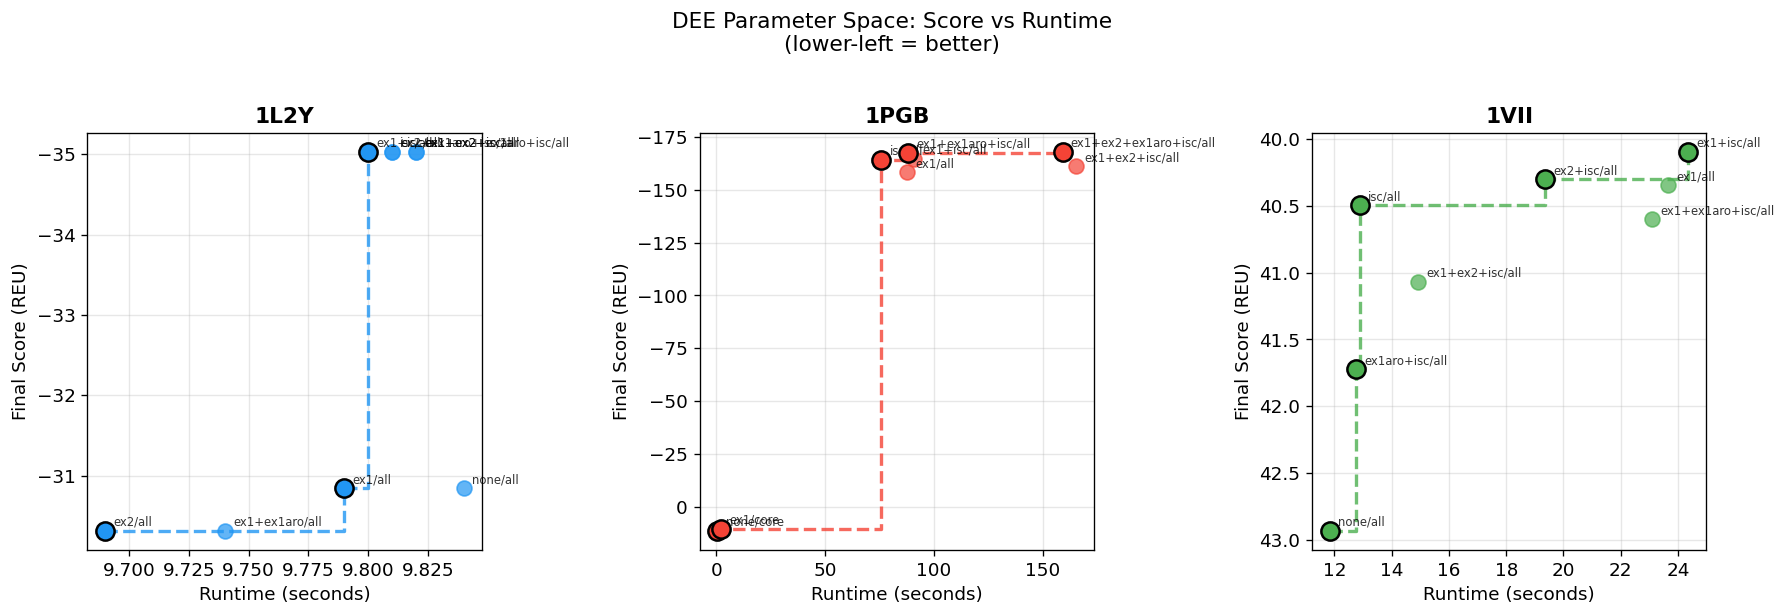

Saved: ../results/pareto_frontier.png


In [7]:
proteins = sorted(df_valid["protein"].unique())
colors = {p: c for p, c in zip(proteins, ["#2196F3", "#F44336", "#4CAF50"])}

fig, axes = plt.subplots(1, len(proteins), figsize=(5 * len(proteins), 5), sharey=False)
if len(proteins) == 1:
    axes = [axes]

def pareto_frontier(df, x_col, y_col):
    """Return rows that are Pareto-optimal (minimize both x and y)."""
    df = df.sort_values(x_col).reset_index(drop=True)
    pareto = []
    min_y = float("inf")
    for _, row in df.iterrows():
        if row[y_col] < min_y:
            min_y = row[y_col]
            pareto.append(row)
    return pd.DataFrame(pareto)

for ax, protein in zip(axes, proteins):
    sub = df_valid[df_valid["protein"] == protein].copy()
    color = colors[protein]

    # Scatter all runs
    ax.scatter(
        sub["runtime_seconds"], sub["final_score"],
        c=color, alpha=0.7, s=80, zorder=3
    )

    # Label each point with its config
    for _, row in sub.iterrows():
        ax.annotate(
            row["config"],
            (row["runtime_seconds"], row["final_score"]),
            textcoords="offset points", xytext=(5, 3),
            fontsize=7, alpha=0.8
        )

    # Pareto frontier
    pareto = pareto_frontier(sub, "runtime_seconds", "final_score")
    if len(pareto) > 1:
        ax.step(
            pareto["runtime_seconds"], pareto["final_score"],
            where="post", color=color, linewidth=2,
            linestyle="--", alpha=0.8, label="Pareto frontier"
        )
        ax.scatter(
            pareto["runtime_seconds"], pareto["final_score"],
            c=color, s=120, zorder=4, edgecolors="black", linewidth=1.5
        )

    ax.set_title(f"{protein}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Runtime (seconds)")
    ax.set_ylabel("Final Score (REU)")
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()  # lower score is better, so invert so "better" is up

plt.suptitle("DEE Parameter Space: Score vs Runtime\n(lower-left = better)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/pareto_frontier.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/pareto_frontier.png")

## 4. Parameter sensitivity — which flags matter most?

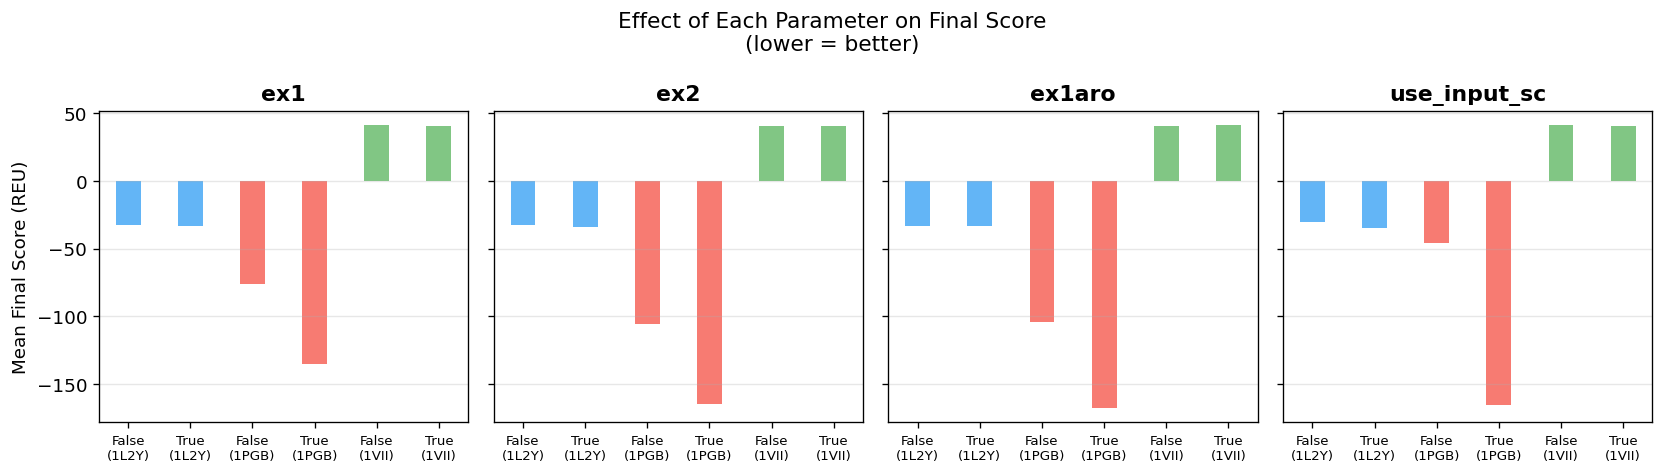

Saved: ../results/parameter_sensitivity.png


In [13]:
params = ["ex1", "ex2", "ex1aro", "use_input_sc"]

fig, axes = plt.subplots(1, len(params), figsize=(14, 4), sharey=True)

for ax, param in zip(axes, params):
    for protein in proteins:
        sub = df_valid[df_valid["protein"] == protein]
        means = sub.groupby(param)["final_score"].mean()
        labels = [f"True" if v else f"False" for v in means.index]
        ax.bar(
            [l + f"\n({protein})" for l in labels],
            means.values,
            color=colors[protein], alpha=0.7, width=0.4,
        )

    ax.set_title(param, fontweight="bold")
    ax.set_ylabel("Mean Final Score (REU)" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3, axis="y")
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Effect of Each Parameter on Final Score\n(lower = better)",
             fontsize=13)
plt.tight_layout()
plt.savefig("../results/parameter_sensitivity.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/parameter_sensitivity.png")

## 5. Rotamers vs Score — pruning efficiency

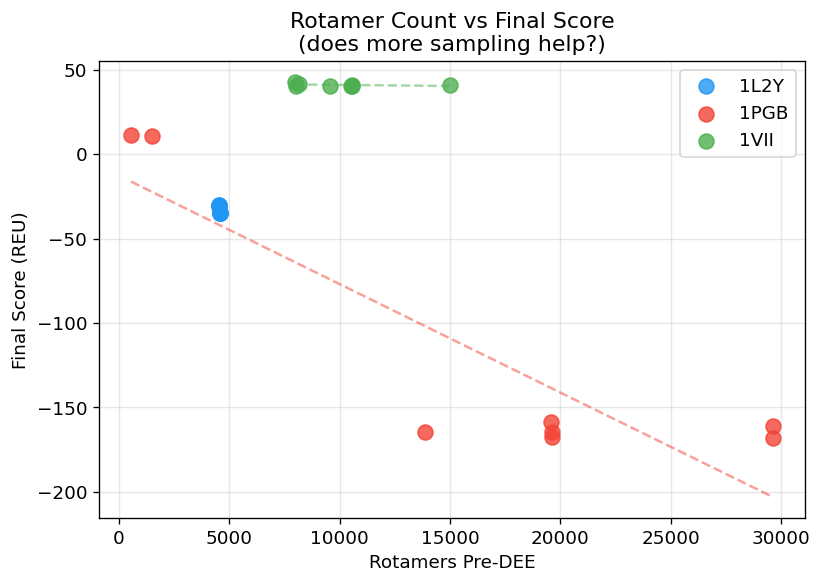

Saved: ../results/rotamers_vs_score.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for protein in proteins:
    sub = df_valid[df_valid["protein"] == protein]
    ax.scatter(
        sub["rotamers_pre_dee"], sub["final_score"],
        label=protein, color=colors[protein],
        alpha=0.8, s=80
    )
    # Trend line
    if len(sub) > 2:
        z = np.polyfit(sub["rotamers_pre_dee"], sub["final_score"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sub["rotamers_pre_dee"].min(),
                              sub["rotamers_pre_dee"].max(), 100)
        ax.plot(x_range, p(x_range), color=colors[protein],
                linestyle="--", alpha=0.5)

ax.set_xlabel("Rotamers Pre-DEE")
ax.set_ylabel("Final Score (REU)")
ax.set_title("Rotamer Count vs Final Score\n(does more sampling help?)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/rotamers_vs_score.png", bbox_inches="tight")
plt.show()
print("Saved: ../results/rotamers_vs_score.png")

## 6. Cross-protein comparison — baseline vs best agent config

In [10]:
# Dahiyat & Mayo paper-faithful config: no extra sampling, all residues
paper_config = df_valid[
    (df_valid["ex1"] == False) &
    (df_valid["ex2"] == False) &
    (df_valid["ex1aro"] == False) &
    (df_valid["use_input_sc"] == False) &
    (df_valid["designable_region"] == "all")
]

# Modern baseline: ex1+ex2, all residues
modern_config = df_valid[
    (df_valid["ex1"] == True) &
    (df_valid["ex2"] == True) &
    (df_valid["designable_region"] == "all")
]

# Best agent config per protein (lowest final score)
best_agent = df_valid.loc[df_valid.groupby("protein")["final_score"].idxmin()]

print("=== Paper-faithful config (no extra sampling) ===")
print(paper_config[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee"]].to_string(index=False))

print("\n=== Modern baseline (ex1+ex2) ===")
print(modern_config[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee"]].to_string(index=False))

print("\n=== Best agent-discovered config per protein ===")
print(best_agent[["protein", "config", "final_score", "runtime_seconds", "rotamers_pre_dee", "rationale"]].to_string(index=False))

=== Paper-faithful config (no extra sampling) ===
protein   config  final_score  runtime_seconds  rotamers_pre_dee
   1VII none/all       42.931            11.84              7982
   1L2Y none/all      -30.842             9.84              4558

=== Modern baseline (ex1+ex2) ===
protein                 config  final_score  runtime_seconds  rotamers_pre_dee
   1VII        ex1+ex2+isc/all       41.069            14.92             14992
   1PGB        ex1+ex2+isc/all     -161.192           165.31             29612
   1PGB ex1+ex2+ex1aro+isc/all     -168.144           159.10             29612
   1L2Y        ex1+ex2+isc/all      -35.034             9.82              4575
   1L2Y ex1+ex2+ex1aro+isc/all      -35.034             9.82              4575

=== Best agent-discovered config per protein ===
protein                 config  final_score  runtime_seconds  rotamers_pre_dee                                                                                                                      

## 7. Agent decision log — rationale review

In [11]:
# Print agent rationale for each run in order — useful for writeup
agent_runs = df[df["run_type"] == "agent"].sort_values("timestamp")

for protein in proteins:
    print(f"\n{'='*60}")
    print(f"  {protein}")
    print(f"{'='*60}")
    sub = agent_runs[agent_runs["protein"] == protein]
    for i, (_, row) in enumerate(sub.iterrows(), 1):
        score_str = f"{row['final_score']:.3f} REU" if pd.notna(row['final_score']) else "N/A"
        runtime_str = f"{row['runtime_seconds']:.1f}s" if pd.notna(row['runtime_seconds']) else "N/A"
        print(f"\nRun {i}: {row['config']}")
        print(f"  Score: {score_str} | Runtime: {runtime_str} | Rotamers: {row['rotamers_pre_dee']}")
        print(f"  Rationale: {row['rationale'][:200]}{'...' if len(str(row['rationale'])) > 200 else ''}")


  1L2Y

Run 1: none/all
  Score: -30.842 REU | Runtime: 9.8s | Rotamers: 4558
  Rationale: Baseline run with minimal rotamer sampling (20 residues total). This matches Dahiyat & Mayo's original spirit but with designable_region='all' (appropriate for small proteins). Will establish runtime ...

Run 2: ex1/all
  Score: -30.842 REU | Runtime: 9.8s | Rotamers: 4558
  Rationale: Add ex1 sampling to baseline. This tests whether extra chi1 rotamers (+/-1 SD) improve final energy score while remaining computationally efficient. For a small 20-residue protein, the rotamer count i...

Run 3: ex1+isc/all
  Score: -35.034 REU | Runtime: 9.8s | Rotamers: 4575
  Rationale: Add ex1 + use_input_sc. Including the input sidechain can improve packing if the input structure is high-quality (1L2Y should be). This is a modest modification that respects structural information. E...

Run 4: ex1+ex2+isc/all
  Score: -35.034 REU | Runtime: 9.8s | Rotamers: 4575
  Rationale: Full modern Rosetta default (ex1=Tr

## 8. Key findings summary

In [12]:
print("KEY FINDINGS")
print("="*60)

for protein in proteins:
    sub = df_valid[df_valid["protein"] == protein]
    if sub.empty:
        continue

    best = sub.loc[sub["final_score"].idxmin()]
    fastest = sub.loc[sub["runtime_seconds"].idxmin()]
    paper = sub[
        (sub["ex1"] == False) & (sub["ex2"] == False) &
        (sub["ex1aro"] == False) & (sub["use_input_sc"] == False) &
        (sub["designable_region"] == "all")
    ]
    modern = sub[
        (sub["ex1"] == True) & (sub["ex2"] == True) &
        (sub["designable_region"] == "all")
    ]

    print(f"\n{protein}:")
    print(f"  Best score    : {best['final_score']:.3f} REU  [{best['config']}]  {best['runtime_seconds']:.1f}s")
    print(f"  Fastest       : {fastest['runtime_seconds']:.1f}s  [{fastest['config']}]  score={fastest['final_score']:.3f} REU")
    if not paper.empty:
        p = paper.iloc[0]
        print(f"  Paper-faithful: {p['final_score']:.3f} REU  {p['runtime_seconds']:.1f}s  {p['rotamers_pre_dee']} rotamers")
    if not modern.empty:
        m = modern.iloc[0]
        print(f"  Modern default: {m['final_score']:.3f} REU  {m['runtime_seconds']:.1f}s  {m['rotamers_pre_dee']} rotamers")
    if not paper.empty and not modern.empty:
        p, m = paper.iloc[0], modern.iloc[0]
        score_diff = abs(p['final_score'] - m['final_score'])
        runtime_ratio = m['runtime_seconds'] / p['runtime_seconds']
        print(f"  Tradeoff      : paper config is {runtime_ratio:.1f}x faster, {score_diff:.3f} REU worse")

KEY FINDINGS

1L2Y:
  Best score    : -35.034 REU  [ex1+isc/all]  9.8s
  Fastest       : 9.7s  [ex2/all]  score=-30.313 REU
  Paper-faithful: -30.842 REU  9.8s  4558 rotamers
  Modern default: -35.034 REU  9.8s  4575 rotamers
  Tradeoff      : paper config is 1.0x faster, 4.192 REU worse

1PGB:
  Best score    : -168.144 REU  [ex1+ex2+ex1aro+isc/all]  159.1s
  Fastest       : 0.6s  [none/core]  score=11.458 REU
  Modern default: -161.192 REU  165.3s  29612 rotamers

1VII:
  Best score    : 40.095 REU  [ex1+isc/all]  24.4s
  Fastest       : 11.8s  [none/all]  score=42.931 REU
  Paper-faithful: 42.931 REU  11.8s  7982 rotamers
  Modern default: 41.069 REU  14.9s  14992 rotamers
  Tradeoff      : paper config is 1.3x faster, 1.862 REU worse
